<a href="https://colab.research.google.com/github/Aleksei185/football-odds-lstm/blob/main/notebooks/01_lstm_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Загрузка данных из SQLite


In [5]:
from google.colab import drive
drive.mount('/content/drive')

import sqlite3
import pandas as pd
import numpy as np

db_path = '/content/drive/MyDrive/database.sqlite'
conn = sqlite3.connect(db_path)

print("\nЗагрузка таблицы Match (только Bet365)")
query_match = """
SELECT
    m.id AS match_id,
    m.date,
    m.season,
    m.stage,
    m.home_team_api_id,
    m.away_team_api_id,
    m.home_team_goal,
    m.away_team_goal,
    m.B365H, m.B365D, m.B365A
FROM Match m
WHERE m.date IS NOT NULL
"""
df_matches = pd.read_sql_query(query_match, conn)
print(f"Загружено {len(df_matches)} матчей")

print("\nЗагрузка таблицы Team...")
df_teams = pd.read_sql_query("SELECT team_api_id, team_long_name FROM Team", conn)
print(f"Загружено {len(df_teams)} команд")

# Загружаем таблицу Team_Attributes (БЕЗ buildUpPlayDribbling)
print("\nЗагрузка таблицы Team_Attributes...")
query_team_attr = """
SELECT
    team_api_id,
    date,
    buildUpPlaySpeed,
    buildUpPlayPassing,
    chanceCreationPassing,
    chanceCreationCrossing,
    chanceCreationShooting,
    defencePressure,
    defenceAggression,
    defenceTeamWidth
FROM Team_Attributes
"""
df_team_attr = pd.read_sql_query(query_team_attr, conn)
df_team_attr['date'] = pd.to_datetime(df_team_attr['date'])
print(f"Загружено {len(df_team_attr)} записей об атрибутах")

# Объединяем матчи с названиями команд
print("\nОбъединение с названиями команд")
df_matches['date'] = pd.to_datetime(df_matches['date'])

df_matches = df_matches.merge(
    df_teams, left_on='home_team_api_id', right_on='team_api_id', how='left'
).rename(columns={'team_long_name': 'home_team_name'}).drop('team_api_id', axis=1)

df_matches = df_matches.merge(
    df_teams, left_on='away_team_api_id', right_on='team_api_id', how='left'
).rename(columns={'team_long_name': 'away_team_name'}).drop('team_api_id', axis=1)
print("Названия команд добавлены")

# Объединение с атрибутами через merge_asof
print("\nОбъединение с атрибутами команд (оптимизированно)")

df_matches = df_matches.sort_values('date')
df_team_attr = df_team_attr.sort_values('date')

def merge_attributes_fast(matches, attributes, team_col, prefix):
    attrs = attributes.rename(columns={'team_api_id': team_col})
    matches_sorted = matches.sort_values('date')
    attrs_sorted = attrs.sort_values('date')

    merged = pd.merge_asof(
        matches_sorted,
        attrs_sorted,
        on='date',
        by=team_col,
        direction='nearest'
    )

    attr_cols = ['buildUpPlaySpeed', 'buildUpPlayPassing',
                 'chanceCreationPassing', 'chanceCreationCrossing', 'chanceCreationShooting',
                 'defencePressure', 'defenceAggression', 'defenceTeamWidth']

    for col in attr_cols:
        merged.rename(columns={col: f'{prefix}_{col}'}, inplace=True)

    return merged

df_matches = merge_attributes_fast(df_matches, df_team_attr, 'home_team_api_id', 'home')
df_matches = merge_attributes_fast(df_matches, df_team_attr, 'away_team_api_id', 'away')

print("Атрибуты команд добавлены")

# 7. Удаляем строки с пропусками (ТОЛЬКО Bet365 + атрибуты)
print("\nУдаление строк с пропусками...")

# Список колонок, где не должно быть пропусков
cols_to_check = ['B365H', 'B365D', 'B365A'] + [col for col in df_matches.columns if col.startswith('home_') or col.startswith('away_')]

df_matches = df_matches.dropna(subset=cols_to_check)
print(f"Осталось {len(df_matches)} матчей после удаления пропусков")

# 8. Выводим итоговую информацию
print("\n" + "="*60)
print("ИТОГОВАЯ ИНФОРМАЦИЯ О ДАННЫХ")
print("="*60)
print(f"Размер датасета: {df_matches.shape[0]} строк, {df_matches.shape[1]} колонок")
print(f"\nСписок колонок ({len(df_matches.columns)}):")
print(df_matches.columns.tolist())
print(f"\nПервые 3 строки:")
display(df_matches.head(3))
print(f"\nПропуски в данных:")
print(df_matches.isnull().sum().sum(), "пропусков")

conn.close()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Загрузка таблицы Match (только Bet365)
Загружено 25979 матчей

Загрузка таблицы Team...
Загружено 299 команд

Загрузка таблицы Team_Attributes...
Загружено 1458 записей об атрибутах

Объединение с названиями команд
Названия команд добавлены

Объединение с атрибутами команд (оптимизированно)
Атрибуты команд добавлены

Удаление строк с пропусками...
Осталось 22309 матчей после удаления пропусков

ИТОГОВАЯ ИНФОРМАЦИЯ О ДАННЫХ
Размер датасета: 22309 строк, 29 колонок

Список колонок (29):
['match_id', 'date', 'season', 'stage', 'home_team_api_id', 'away_team_api_id', 'home_team_goal', 'away_team_goal', 'B365H', 'B365D', 'B365A', 'home_team_name', 'away_team_name', 'home_buildUpPlaySpeed', 'home_buildUpPlayPassing', 'home_chanceCreationPassing', 'home_chanceCreationCrossing', 'home_chanceCreationShooting', 'home_defencePressure', 'home_defenceAggression', 'home_d

,match_id,date,season,stage,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,B365H,B365D,...,home_defenceAggression,home_defenceTeamWidth,away_buildUpPlaySpeed,away_buildUpPlayPassing,away_chanceCreationPassing,away_chanceCreationCrossing,away_chanceCreationShooting,away_defencePressure,away_defenceAggression,away_defenceTeamWidth
22,4769,2008-08-09,2008/2009,1,8583,9830,2,1,2.10,3.1,...,55.0,30.0,55.0,35.0,60.0,65.0,35.0,30.0,45.0,30.0
23,19694,2008-08-09,2008/2009,1,8596,8548,0,1,6.50,4.0,...,70.0,70.0,65.0,50.0,70.0,70.0,70.0,60.0,70.0,70.0
24,4775,2008-08-09,2008/2009,1,8481,8639,0,0,2.15,3.1,...,70.0,70.0,70.0,60.0,50.0,45.0,55.0,55.0,70.0,55.0



Пропуски в данных:
0 пропусков


Анализ данных и их визуализация

df_matches уже в памяти. Продолжаем.
ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ ДАННЫХ (EDA)

Проверка данных:
Размер: (22309, 32)
Типы данных (первые 10):
match_id                     int64
date                datetime64[ns]
season                      object
stage                        int64
home_team_api_id             int64
away_team_api_id             int64
home_team_goal               int64
away_team_goal               int64
B365H                      float64
B365D                      float64
dtype: object

Пропуски: 0

1. РАСПРЕДЕЛЕНИЕ ИСХОДОВ МАТЧЕЙ
Победа хозяев: 10239 (45.90%)
Ничья: 5647 (25.31%)
Победа гостей: 6423 (28.79%)


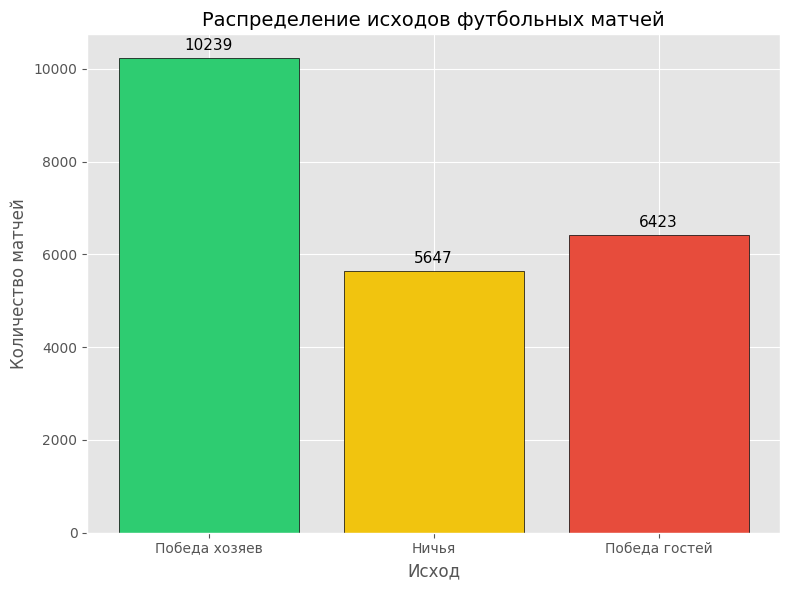


2. РАСПРЕДЕЛЕНИЕ КОЭФФИЦИЕНТОВ BET365


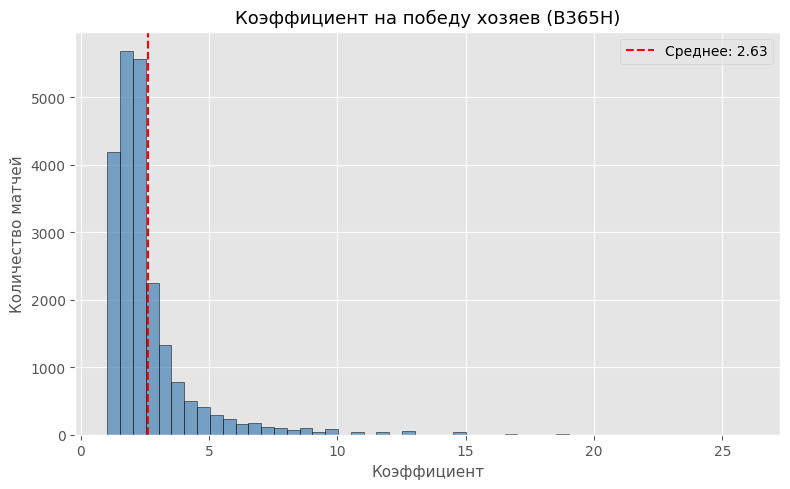

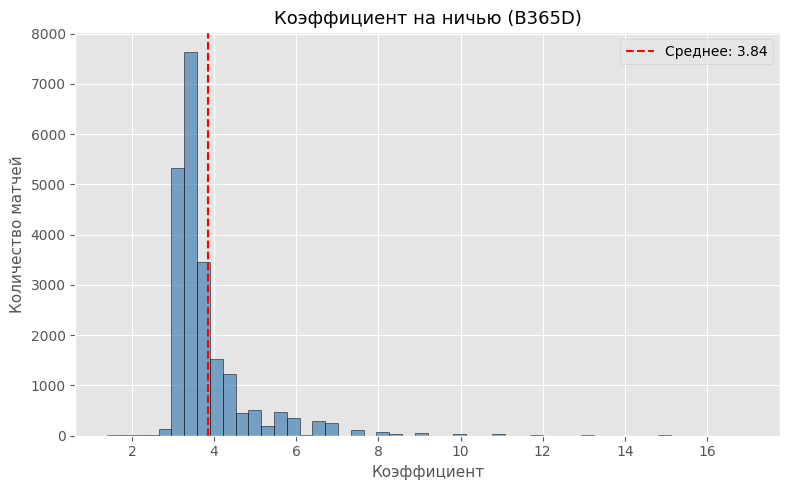

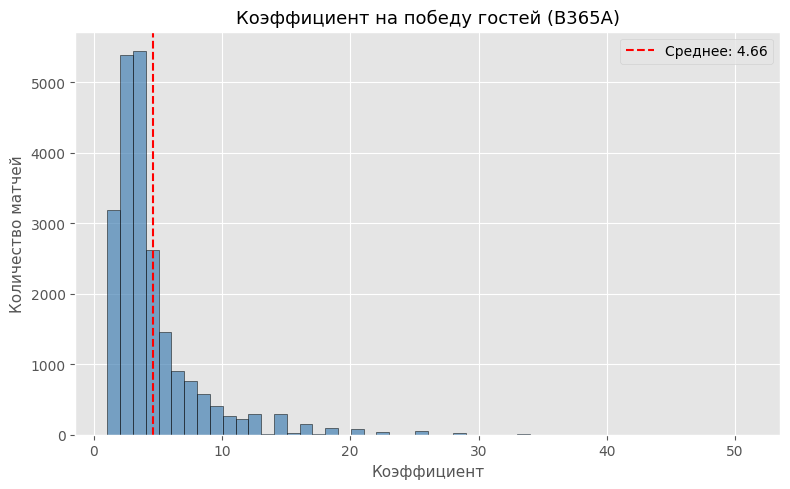


3. СВЯЗЬ КОЭФФИЦИЕНТОВ С ИСХОДОМ


/tmp/ipykernel_1000/1300182854.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


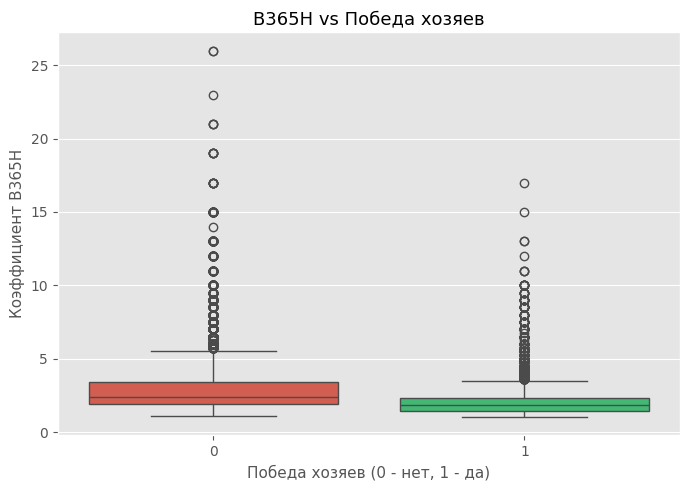

/tmp/ipykernel_1000/1300182854.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


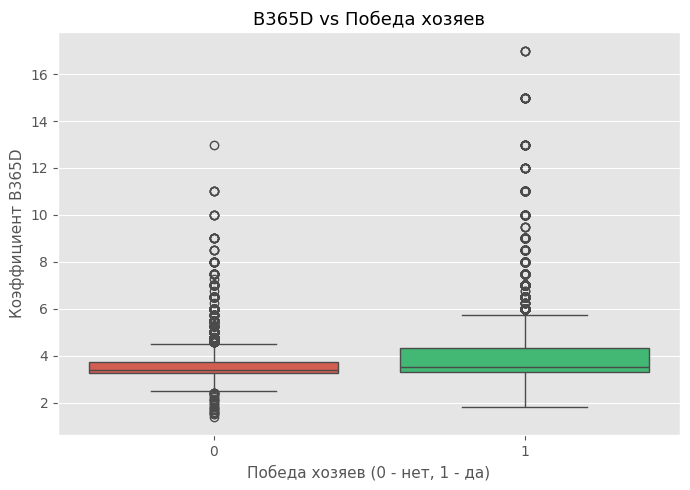

/tmp/ipykernel_1000/1300182854.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


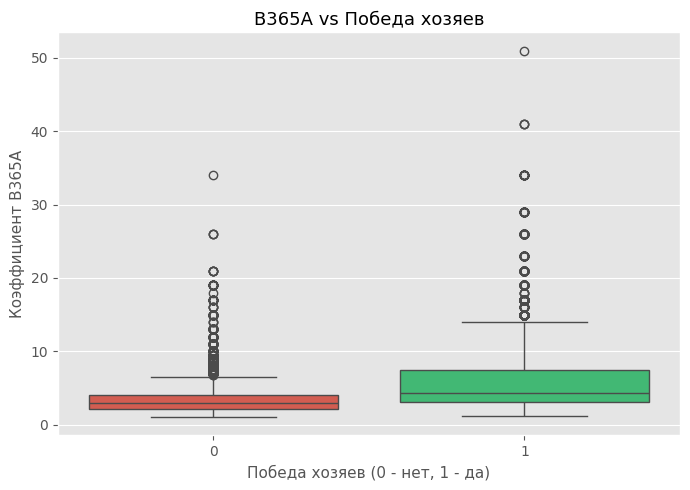


4. МАТРИЦА КОРРЕЛЯЦИЙ
Числовых колонок для корреляции: 24
Список: ['home_team_goal', 'away_team_goal', 'B365H', 'B365D', 'B365A', 'home_buildUpPlaySpeed', 'home_buildUpPlayPassing', 'home_chanceCreationPassing', 'home_chanceCreationCrossing', 'home_chanceCreationShooting', 'home_defencePressure', 'home_defenceAggression', 'home_defenceTeamWidth', 'away_buildUpPlaySpeed', 'away_buildUpPlayPassing', 'away_chanceCreationPassing', 'away_chanceCreationCrossing', 'away_chanceCreationShooting', 'away_defencePressure', 'away_defenceAggression', 'away_defenceTeamWidth', 'home_win', 'draw', 'away_win']


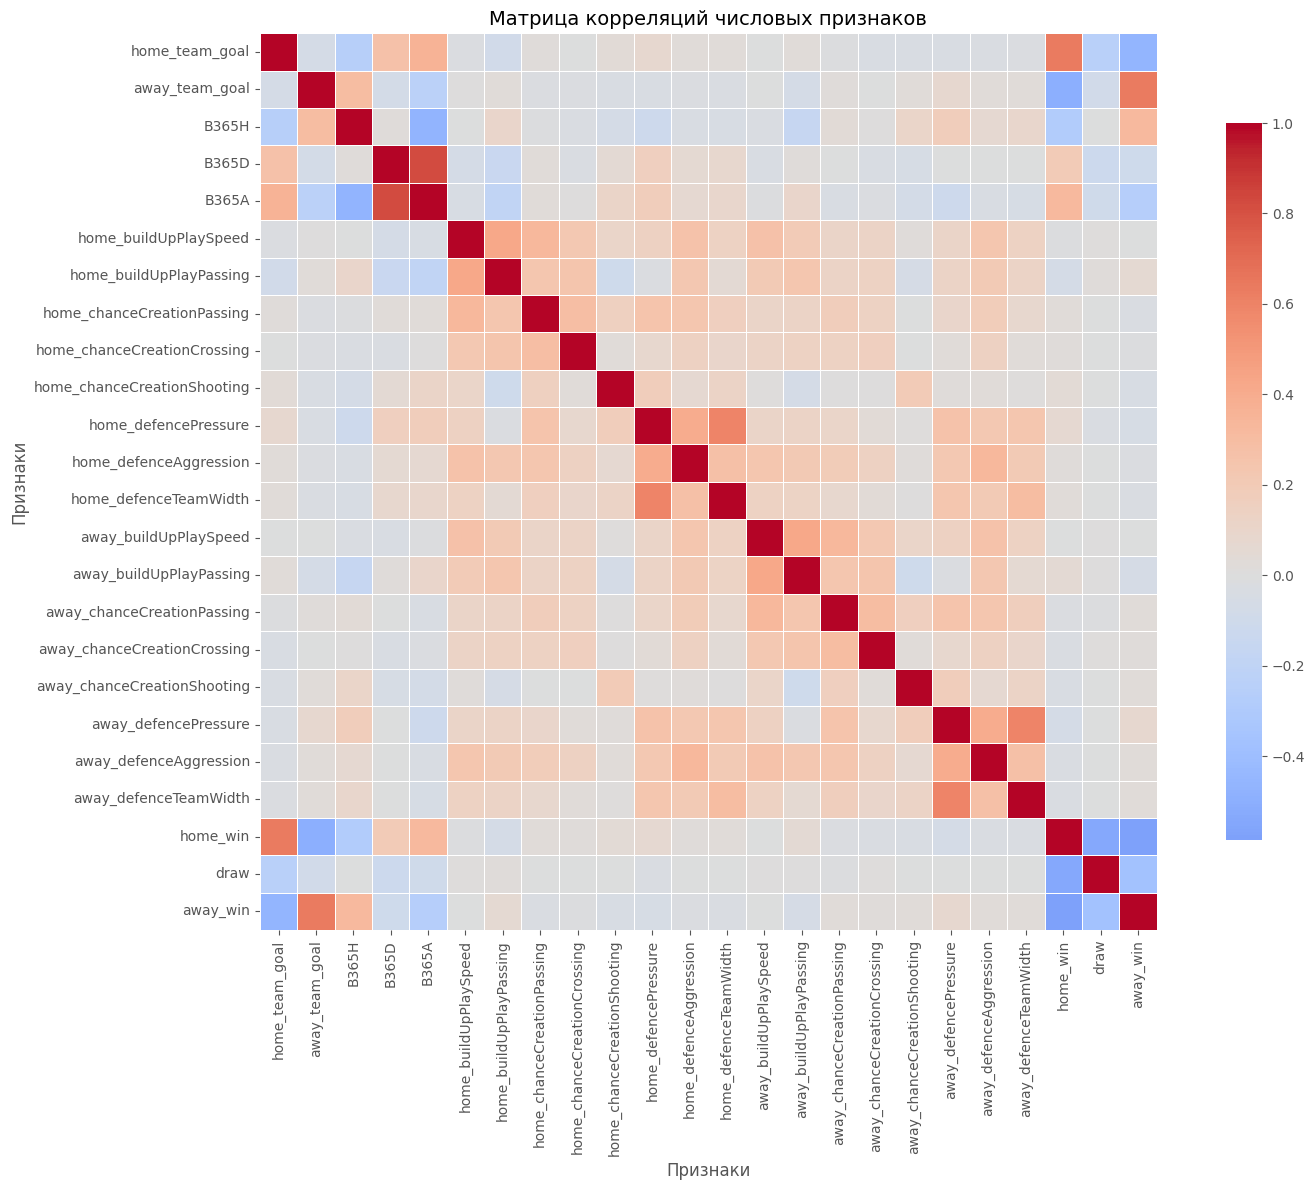


5. КОРРЕЛЯЦИЯ ПРИЗНАКОВ С HOME_WIN
home_team_goal                 0.637115
B365A                          0.320101
B365D                          0.198419
home_defencePressure           0.069425
away_buildUpPlayPassing        0.046344
home_chanceCreationShooting    0.045060
home_defenceTeamWidth          0.023588
home_chanceCreationPassing     0.022699
home_defenceAggression         0.017165
home_chanceCreationCrossing    0.016283
away_buildUpPlaySpeed          0.000361
home_buildUpPlaySpeed         -0.010484
away_chanceCreationPassing    -0.019318
away_defenceAggression        -0.024951
away_chanceCreationCrossing   -0.025802
away_defenceTeamWidth         -0.026688
away_chanceCreationShooting   -0.028388
away_defencePressure          -0.064561
home_buildUpPlayPassing       -0.067649
B365H                         -0.283733
away_team_goal                -0.502107
draw                          -0.536192
away_win                      -0.585648


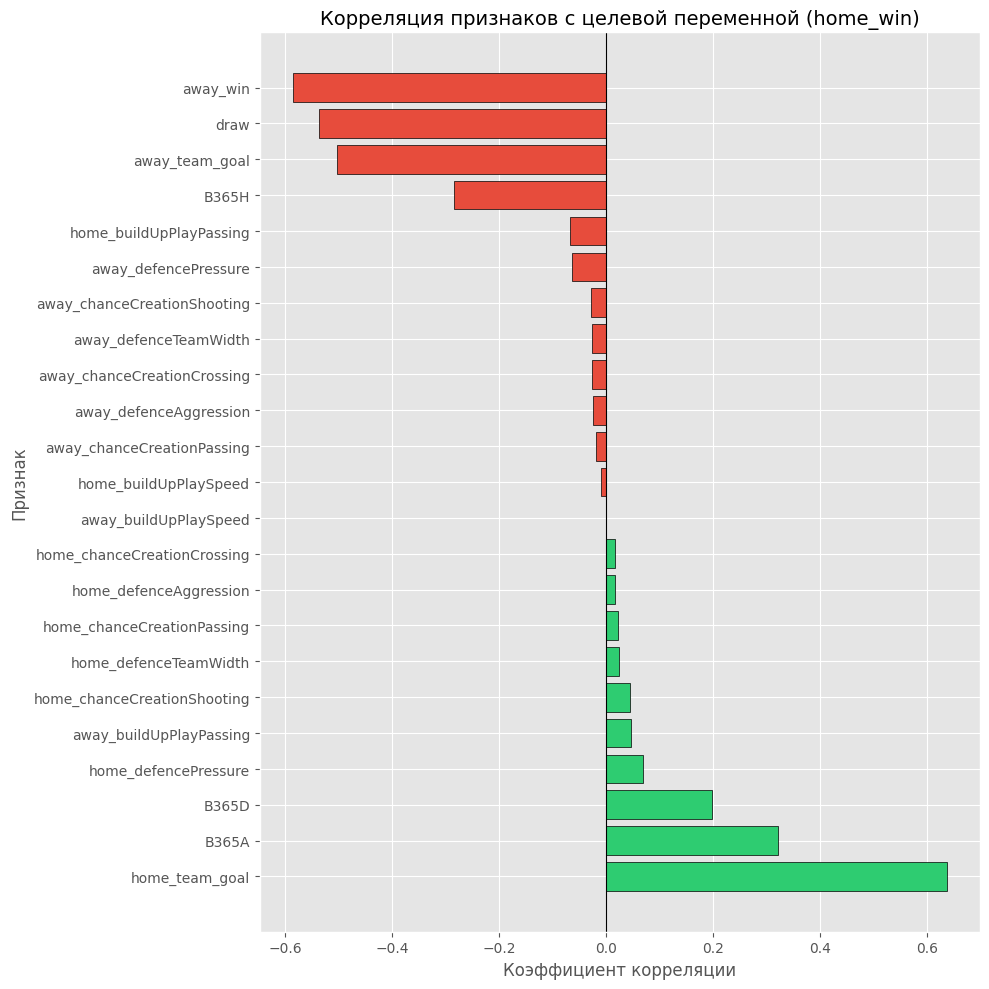


6. АТРИБУТЫ ХОЗЯЕВ (ПОБЕДА vs НЕ ПОБЕДА)
Атрибуты хозяев: ['home_team_api_id', 'home_buildUpPlaySpeed', 'home_buildUpPlayPassing', 'home_chanceCreationPassing', 'home_chanceCreationCrossing', 'home_chanceCreationShooting', 'home_defencePressure', 'home_defenceAggression', 'home_defenceTeamWidth']


/tmp/ipykernel_1000/1300182854.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


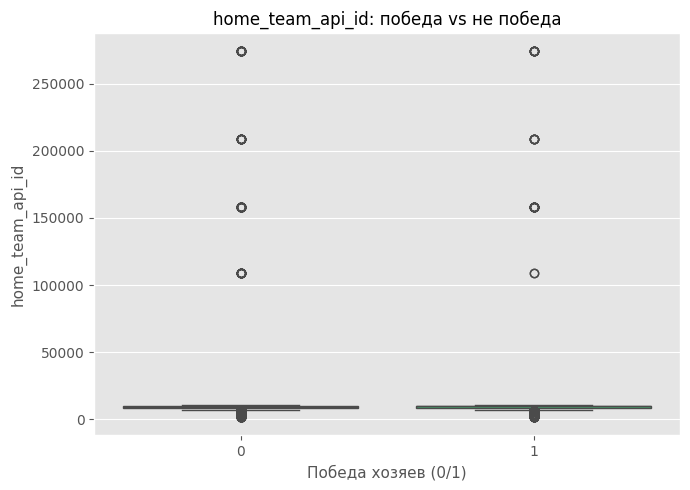

/tmp/ipykernel_1000/1300182854.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


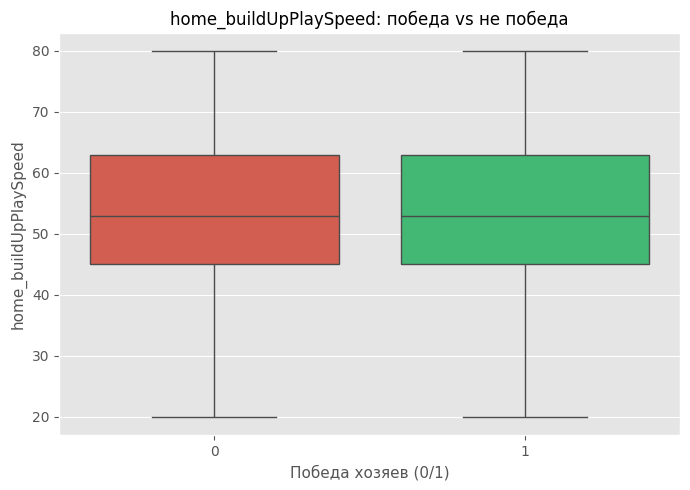

/tmp/ipykernel_1000/1300182854.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


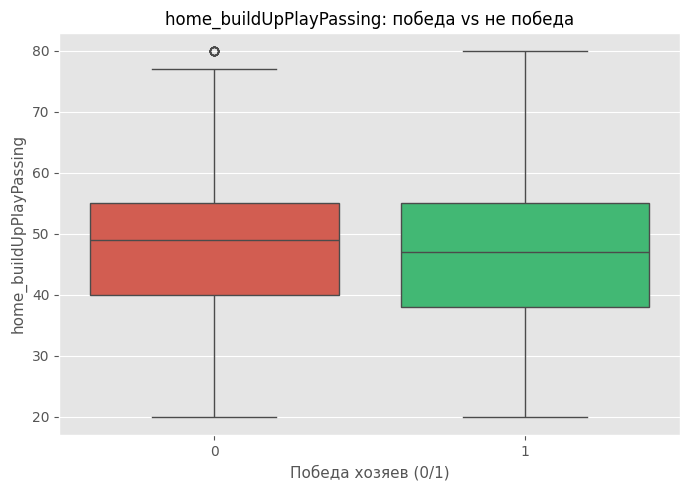

/tmp/ipykernel_1000/1300182854.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


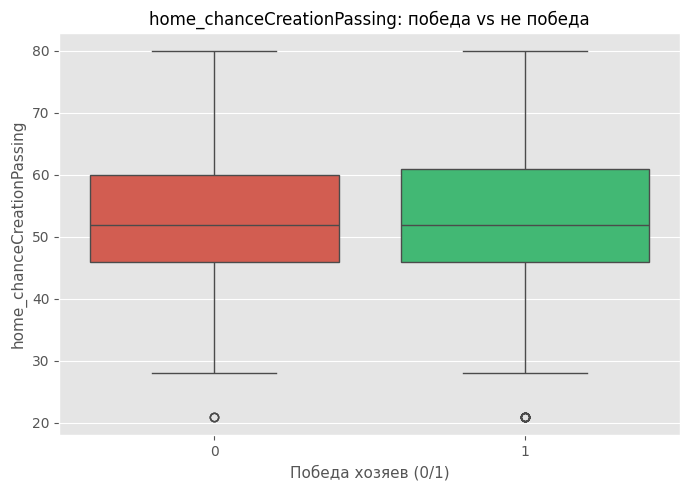

/tmp/ipykernel_1000/1300182854.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


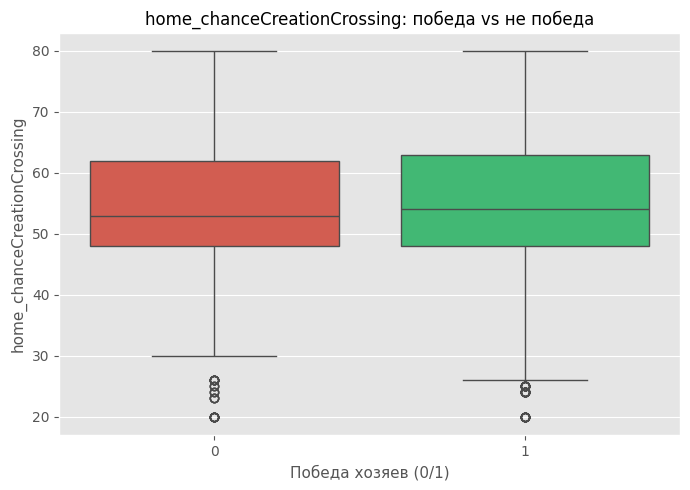

/tmp/ipykernel_1000/1300182854.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


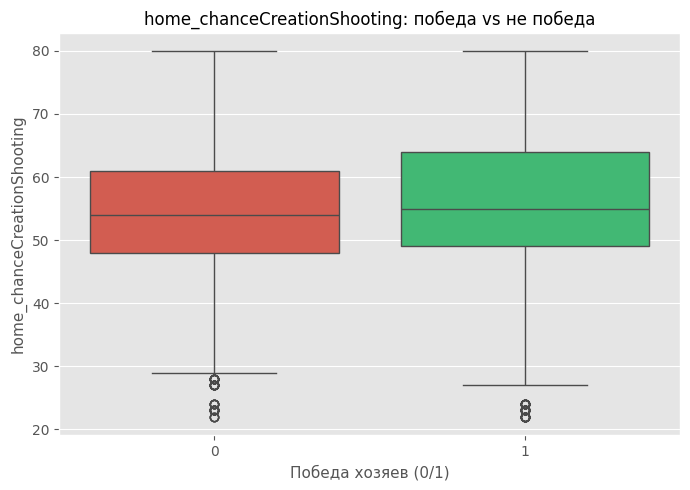

/tmp/ipykernel_1000/1300182854.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


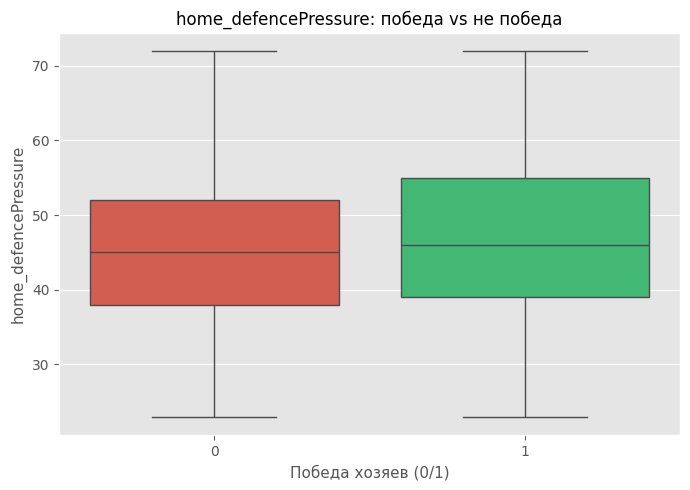

/tmp/ipykernel_1000/1300182854.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


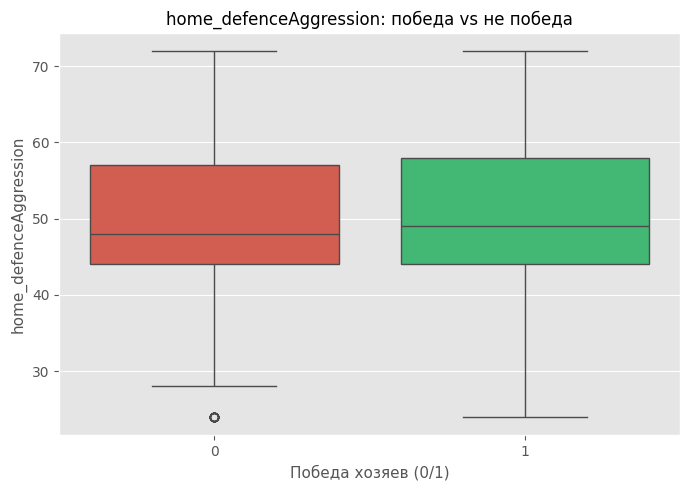

/tmp/ipykernel_1000/1300182854.py:141: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


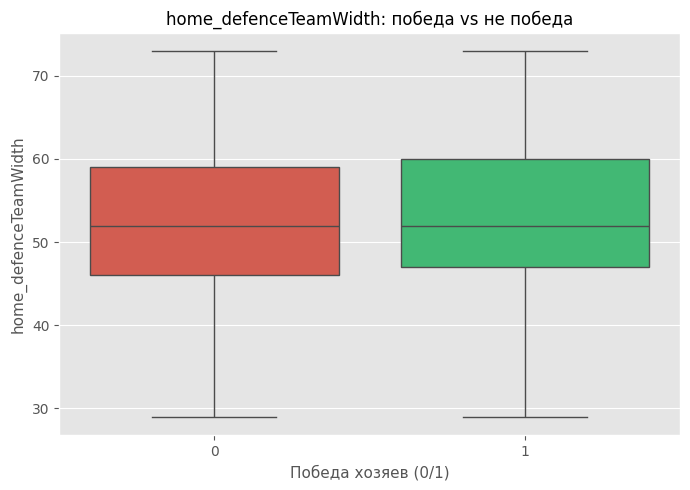


7. АТРИБУТЫ ГОСТЕЙ (ПОБЕДА ХОЗЯЕВ vs НЕ ПОБЕДА)
Атрибуты гостей: ['away_team_api_id', 'away_buildUpPlaySpeed', 'away_buildUpPlayPassing', 'away_chanceCreationPassing', 'away_chanceCreationCrossing', 'away_chanceCreationShooting', 'away_defencePressure', 'away_defenceAggression', 'away_defenceTeamWidth', 'away_win']


/tmp/ipykernel_1000/1300182854.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


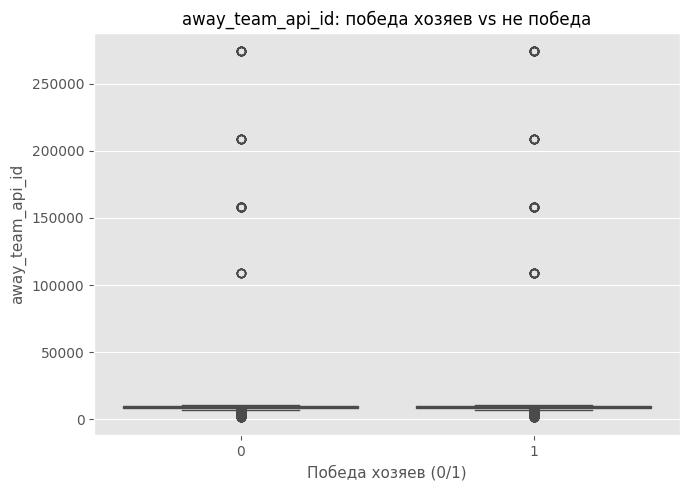

/tmp/ipykernel_1000/1300182854.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


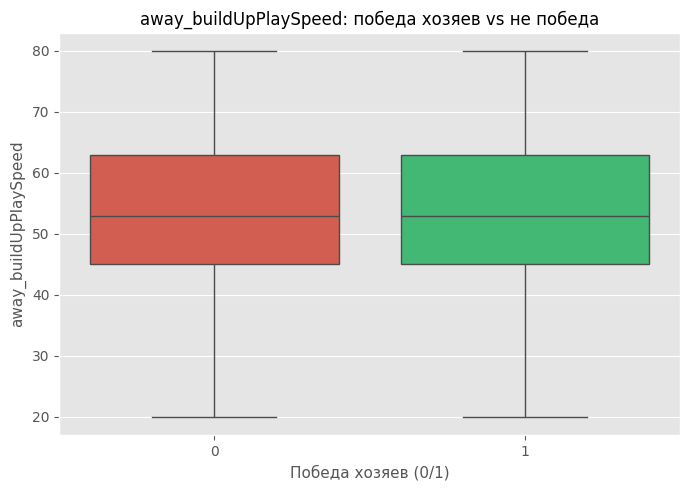

/tmp/ipykernel_1000/1300182854.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


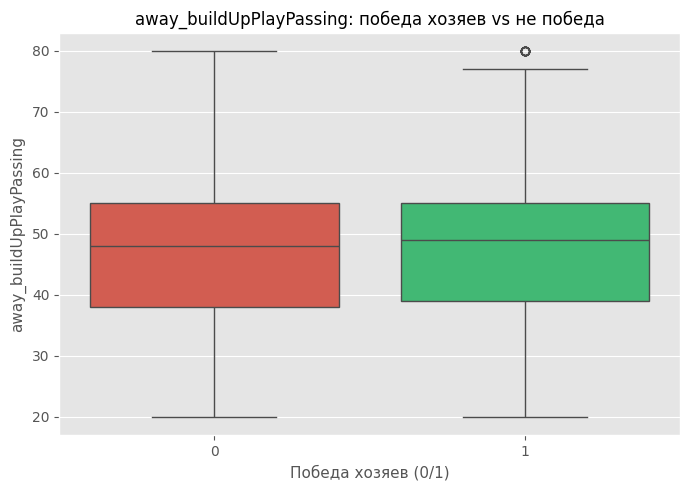

/tmp/ipykernel_1000/1300182854.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


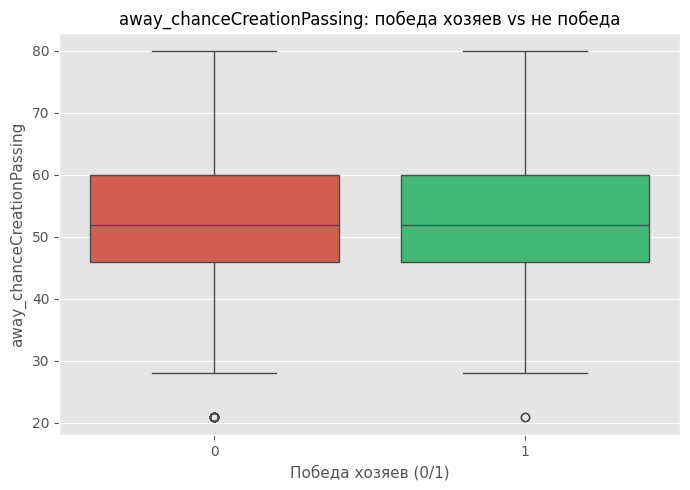

/tmp/ipykernel_1000/1300182854.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


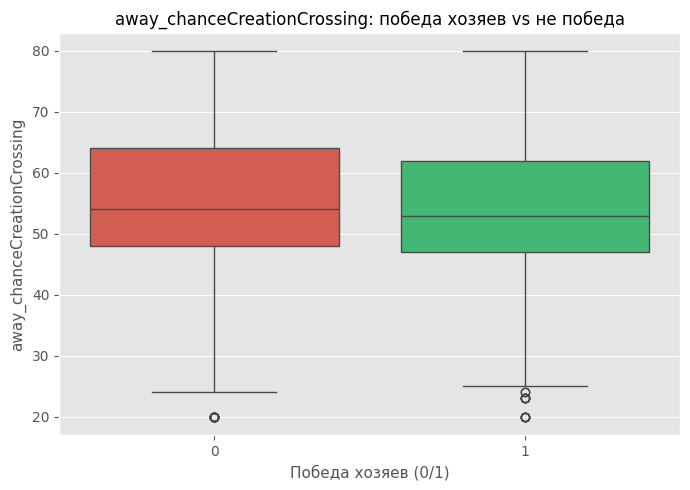

/tmp/ipykernel_1000/1300182854.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


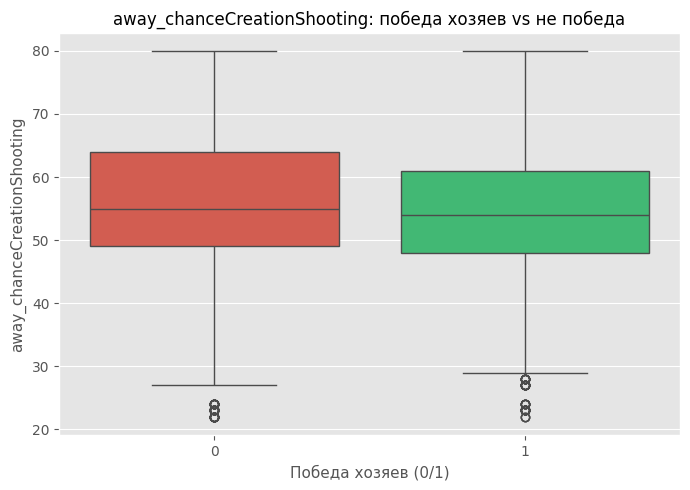

/tmp/ipykernel_1000/1300182854.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


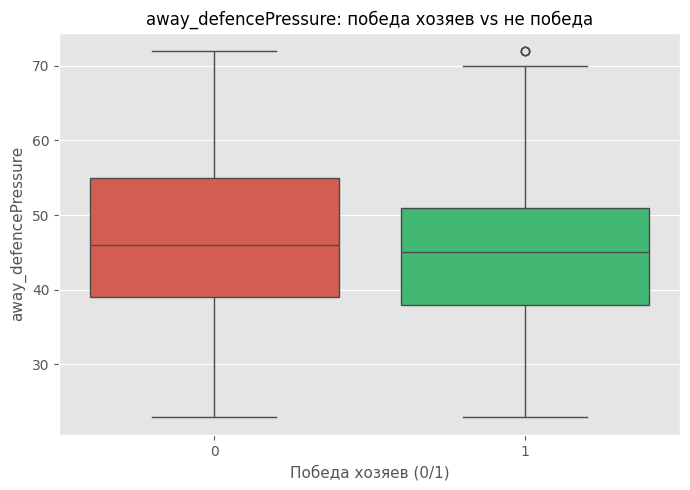

/tmp/ipykernel_1000/1300182854.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


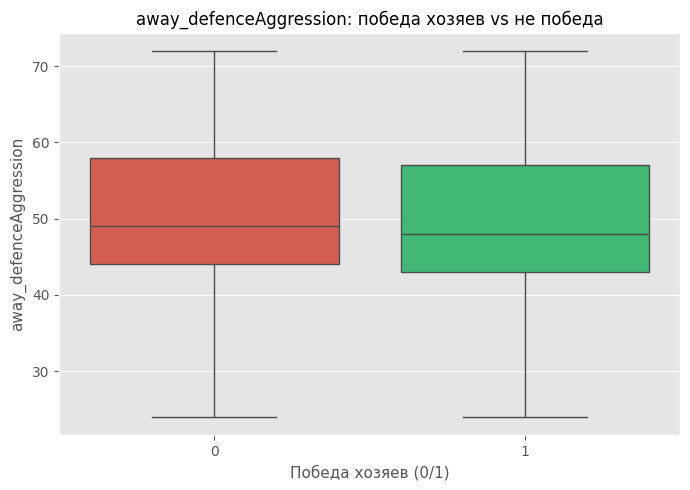

/tmp/ipykernel_1000/1300182854.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


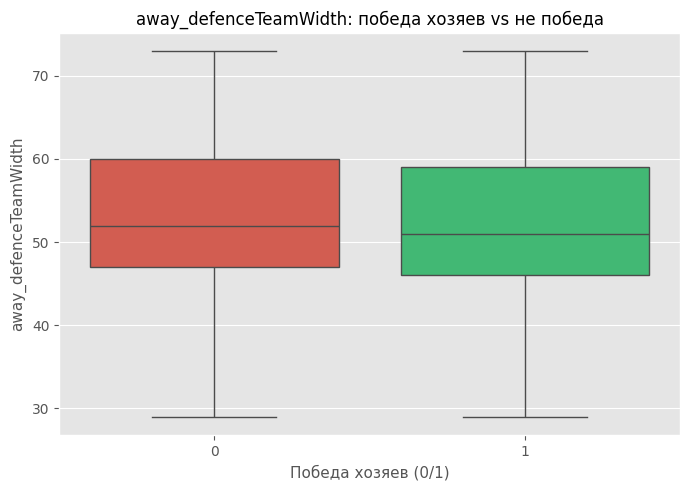

/tmp/ipykernel_1000/1300182854.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])


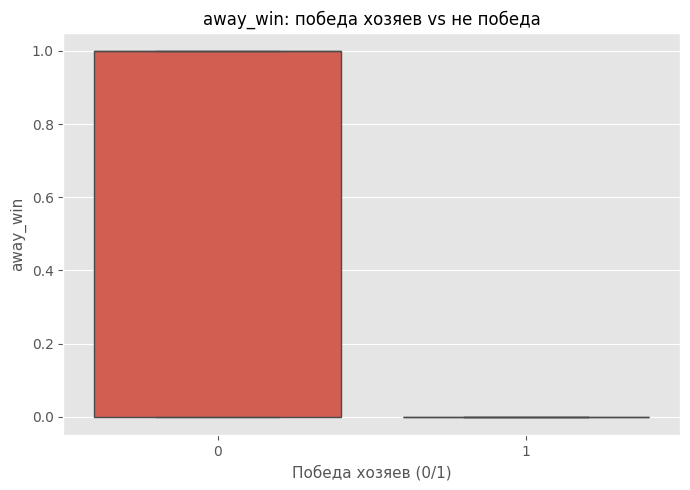


8. БАЛАНС КЛАССОВ (HOME_WIN)
Класс 0 (не победа хозяев): 12070 (54.10%)
Класс 1 (победа хозяев): 10239 (45.90%)


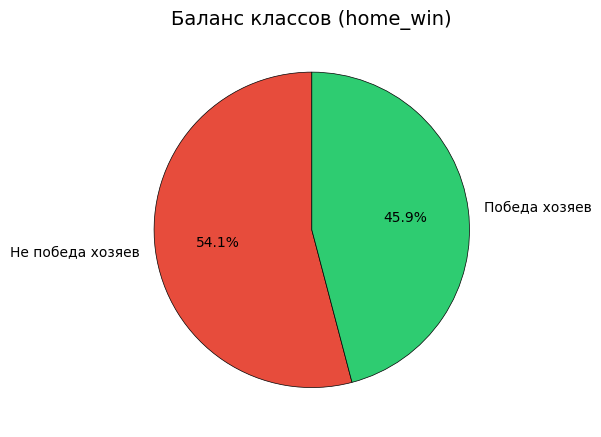


ЭТАП 2 ЗАВЕРШЕН


In [9]:
try:
    df_matches
    print("df_matches уже в памяти. Продолжаем.")
except NameError:
    print("ОШИБКА: df_matches не найдена. Выполните Этап 1 заново.")
    raise

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (10, 6)

print("="*60)
print("ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ ДАННЫХ (EDA)")
print("="*60)

# ПРОВЕРКА ДАННЫХ
print("\nПроверка данных:")
print(f"Размер: {df_matches.shape}")
print(f"Типы данных (первые 10):")
print(df_matches.dtypes.head(10))
print(f"\nПропуски: {df_matches.isnull().sum().sum()}")

# 1. СОЗДАНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
df_matches['home_win'] = (df_matches['home_team_goal'] > df_matches['away_team_goal']).astype(int)
df_matches['draw'] = (df_matches['home_team_goal'] == df_matches['away_team_goal']).astype(int)
df_matches['away_win'] = (df_matches['home_team_goal'] < df_matches['away_team_goal']).astype(int)

print("\n" + "="*60)
print("1. РАСПРЕДЕЛЕНИЕ ИСХОДОВ МАТЧЕЙ")
print("="*60)

outcome_counts = df_matches[['home_win', 'draw', 'away_win']].sum()
print(f"Победа хозяев: {outcome_counts['home_win']} ({outcome_counts['home_win']/len(df_matches)*100:.2f}%)")
print(f"Ничья: {outcome_counts['draw']} ({outcome_counts['draw']/len(df_matches)*100:.2f}%)")
print(f"Победа гостей: {outcome_counts['away_win']} ({outcome_counts['away_win']/len(df_matches)*100:.2f}%)")

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(['Победа хозяев', 'Ничья', 'Победа гостей'],
              outcome_counts.values, color=['#2ecc71', '#f1c40f', '#e74c3c'], edgecolor='black')
ax.set_title('Распределение исходов футбольных матчей', fontsize=14)
ax.set_xlabel('Исход', fontsize=12)
ax.set_ylabel('Количество матчей', fontsize=12)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 100,
            f'{int(height)}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

# 2. РАСПРЕДЕЛЕНИЕ КОЭФФИЦИЕНТОВ BET365
print("\n" + "="*60)
print("2. РАСПРЕДЕЛЕНИЕ КОЭФФИЦИЕНТОВ BET365")
print("="*60)

for col, title in zip(['B365H', 'B365D', 'B365A'],
                      ['Коэффициент на победу хозяев (B365H)',
                       'Коэффициент на ничью (B365D)',
                       'Коэффициент на победу гостей (B365A)']):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(df_matches[col], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Коэффициент', fontsize=11)
    ax.set_ylabel('Количество матчей', fontsize=11)
    ax.axvline(df_matches[col].mean(), color='red', linestyle='--',
               label=f'Среднее: {df_matches[col].mean():.2f}')
    ax.legend()
    plt.tight_layout()
    plt.show()

# 3. СВЯЗЬ КОЭФФИЦИЕНТОВ С ИСХОДОМ
print("\n" + "="*60)
print("3. СВЯЗЬ КОЭФФИЦИЕНТОВ С ИСХОДОМ")
print("="*60)

for col in ['B365H', 'B365D', 'B365A']:
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])
    ax.set_title(f'{col} vs Победа хозяев', fontsize=13)
    ax.set_xlabel('Победа хозяев (0 - нет, 1 - да)', fontsize=11)
    ax.set_ylabel(f'Коэффициент {col}', fontsize=11)
    plt.tight_layout()
    plt.show()

# 4. МАТРИЦА КОРРЕЛЯЦИЙ
print("\n" + "="*60)
print("4. МАТРИЦА КОРРЕЛЯЦИЙ")
print("="*60)

# Определяем числовые колонки автоматически
numeric_cols = df_matches.select_dtypes(include=[np.number]).columns.tolist()
# Убираем служебные
numeric_cols = [col for col in numeric_cols if col not in
                ('match_id', 'home_team_api_id', 'away_team_api_id', 'stage')]

print(f"Числовых колонок для корреляции: {len(numeric_cols)}")
print(f"Список: {numeric_cols}")

corr_matrix = df_matches[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Матрица корреляций числовых признаков', fontsize=14)
ax.set_xlabel('Признаки', fontsize=12)
ax.set_ylabel('Признаки', fontsize=12)
plt.tight_layout()
plt.show()

# 5. КОРРЕЛЯЦИЯ С ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
print("\n" + "="*60)
print("5. КОРРЕЛЯЦИЯ ПРИЗНАКОВ С HOME_WIN")
print("="*60)

corr_with_target = df_matches[numeric_cols].corr()['home_win'].drop('home_win').sort_values(ascending=False)
print(corr_with_target.to_string())

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in corr_with_target.values]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors, edgecolor='black')
ax.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax.set_title('Корреляция признаков с целевой переменной (home_win)', fontsize=14)
ax.set_xlabel('Коэффициент корреляции', fontsize=12)
ax.set_ylabel('Признак', fontsize=12)
plt.tight_layout()
plt.show()

# 6. АТРИБУТЫ ХОЗЯЕВ (ПОБЕДА vs НЕ ПОБЕДА)
print("\n" + "="*60)
print("6. АТРИБУТЫ ХОЗЯЕВ (ПОБЕДА vs НЕ ПОБЕДА)")
print("="*60)

home_attr_cols = [col for col in df_matches.columns
                  if col.startswith('home_') and col not in ('home_team_name', 'home_win', 'home_team_goal')]
print(f"Атрибуты хозяев: {home_attr_cols}")

for col in home_attr_cols:
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])
    ax.set_title(f'{col}: победа vs не победа', fontsize=12)
    ax.set_xlabel('Победа хозяев (0/1)', fontsize=11)
    ax.set_ylabel(col, fontsize=11)
    plt.tight_layout()
    plt.show()

# 7. АТРИБУТЫ ГОСТЕЙ (ПОБЕДА ХОЗЯЕВ vs НЕ ПОБЕДА)
print("\n" + "="*60)
print("7. АТРИБУТЫ ГОСТЕЙ (ПОБЕДА ХОЗЯЕВ vs НЕ ПОБЕДА)")
print("="*60)

away_attr_cols = [col for col in df_matches.columns
                  if col.startswith('away_') and col not in ('away_team_name', 'away_team_goal')]
print(f"Атрибуты гостей: {away_attr_cols}")

for col in away_attr_cols:
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.boxplot(x='home_win', y=col, data=df_matches, ax=ax, palette=['#e74c3c', '#2ecc71'])
    ax.set_title(f'{col}: победа хозяев vs не победа', fontsize=12)
    ax.set_xlabel('Победа хозяев (0/1)', fontsize=11)
    ax.set_ylabel(col, fontsize=11)
    plt.tight_layout()
    plt.show()

# 8. БАЛАНС КЛАССОВ
print("\n" + "="*60)
print("8. БАЛАНС КЛАССОВ (HOME_WIN)")
print("="*60)

balance = df_matches['home_win'].value_counts()
print(f"Класс 0 (не победа хозяев): {balance[0]} ({balance[0]/len(df_matches)*100:.2f}%)")
print(f"Класс 1 (победа хозяев): {balance[1]} ({balance[1]/len(df_matches)*100:.2f}%)")

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(balance.values, labels=['Не победа хозяев', 'Победа хозяев'],
       autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90,
       wedgeprops={'edgecolor': 'black'})
ax.set_title('Баланс классов (home_win)', fontsize=14)
plt.tight_layout()
plt.show()

Feature Engineering

In [11]:
# СОЗДАНИЕ ПРОИЗВОДНЫХ ПРИЗНАКОВ
print("\n" + "="*60)
print("СОЗДАНИЕ ПРОИЗВОДНЫХ ПРИЗНАКОВ")
print("="*60)

# Implied probabilities (вероятности исходов)
df_matches['implied_prob_H'] = 1 / df_matches['B365H']
df_matches['implied_prob_D'] = 1 / df_matches['B365D']
df_matches['implied_prob_A'] = 1 / df_matches['B365A']
print("Созданы признаки: implied_prob_H, implied_prob_D, implied_prob_A")

# Odds ratios (соотношения коэффициентов)
df_matches['odds_ratio_HA'] = df_matches['B365H'] / df_matches['B365A']
df_matches['odds_ratio_HD'] = df_matches['B365H'] / df_matches['B365D']
df_matches['odds_ratio_AD'] = df_matches['B365A'] / df_matches['B365D']
print("Созданы признаки: odds_ratio_HA, odds_ratio_HD, odds_ratio_AD")

print("\n" + "="*60)
print("ФОРМИРОВАНИЕ ИТОГОВОГО ДАТАСЕТА")
print("="*60)

# Список признаков для модели
feature_cols = [
    'B365H', 'B365D', 'B365A',
    'implied_prob_H', 'implied_prob_D', 'implied_prob_A',
    'odds_ratio_HA', 'odds_ratio_HD', 'odds_ratio_AD'
]

# Целевая переменная
target_col = 'home_win'

df_final = df_matches[feature_cols + [target_col]].copy()

print(f"Итоговый датасет: {df_final.shape[0]} строк, {df_final.shape[1]} колонок")
print(f"\nПризнаки ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")
print(f"\nЦелевая переменная: {target_col}")

# ПРОВЕРКА ПРОПУСКОВ И ТИПОВ
print("\n" + "="*60)
print("ПРОВЕРКА ДАННЫХ")
print("="*60)

print(f"Пропуски: {df_final.isnull().sum().sum()}")
print(f"\nТипы данных:")
print(df_final.dtypes)

# БАЗОВАЯ СТАТИСТИКА
print("\n" + "="*60)
print("БАЗОВАЯ СТАТИСТИКА ПРИЗНАКОВ")
print("="*60)

print(df_final.describe().T.to_string())

# ВЫВОД ПЕРВЫХ СТРОК
print("\n" + "="*60)
print("ПЕРВЫЕ 5 СТРОК ИТОГОВОГО ДАТАСЕТА")
print("="*60)

print(df_final.head().to_string())

# Сохраняем итоговый датасет в переменную df_final

print("Итоговый датасет сохранен в переменную 'df_final'")
print(f"Размер: {df_final.shape}")
print(f"Признаки: {feature_cols}")
print(f"Целевая переменная: {target_col}")


СОЗДАНИЕ ПРОИЗВОДНЫХ ПРИЗНАКОВ
Созданы признаки: implied_prob_H, implied_prob_D, implied_prob_A
Созданы признаки: odds_ratio_HA, odds_ratio_HD, odds_ratio_AD

ФОРМИРОВАНИЕ ИТОГОВОГО ДАТАСЕТА
Итоговый датасет: 22309 строк, 10 колонок

Признаки (9):
  1. B365H
  2. B365D
  3. B365A
  4. implied_prob_H
  5. implied_prob_D
  6. implied_prob_A
  7. odds_ratio_HA
  8. odds_ratio_HD
  9. odds_ratio_AD

Целевая переменная: home_win

ПРОВЕРКА ДАННЫХ
Пропуски: 0

Типы данных:
B365H             float64
B365D             float64
B365A             float64
implied_prob_H    float64
implied_prob_D    float64
implied_prob_A    float64
odds_ratio_HA     float64
odds_ratio_HD     float64
odds_ratio_AD     float64
home_win            int64
dtype: object

БАЗОВАЯ СТАТИСТИКА ПРИЗНАКОВ
                  count      mean       std       min       25%       50%       75%        max
B365H           22309.0  2.626414  1.786781  1.040000  1.670000  2.100000  2.800000  26.000000
B365D           22309.0  3.839853 